In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Library Imports ---
sys.path.append('../') 
try:
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: conformalHDC modules not found. Ensure '../' is in path.")

In [2]:
# Fixed Constants
EXP_NAME = "3class"
REPETITIONS = 1
N_PER_CLASS = 2000
SEPARATION = 2.0
LABELS_ID = [0, 1, 2]
SCORE_TYPES = ["sim", "ratio", "discount", "penalized", "inverse_quantile"]
SIGMA_RANGE = np.arange(3, 5, 0.25)

In [3]:
################======== Geometry & Data Utils ========################

def setup_triangle_geometry(separation_factor, rng):
    dim = 2
    ref_sigma = 1.0
    r_ref = ref_sigma * np.sqrt(dim)
    dist = separation_factor * (r_ref + r_ref)

    mu0 = np.array([0.0, 0.0])
    mu1 = np.array([dist, 0.0])
    mu2 = np.array([dist / 2, (np.sqrt(3) / 2) * dist])
    
    return np.stack([mu0, mu1, mu2]).astype(np.float32)

def generate_samples_3class(n_samples, prototypes, sigmas, rng):
    X_list = []
    y_list = []
    dim = prototypes.shape[1]
    
    for label, (mu, sigma) in enumerate(zip(prototypes, sigmas)):
        X_c = rng.randn(n_samples, dim) * sigma + mu
        X_list.append(X_c)
        y_list.append(np.full(n_samples, label))
        
    X = np.concatenate(X_list).astype(np.float32)
    y = np.concatenate(y_list).astype(int)
    return X, y

def generate_ood_blob(n_samples, prototypes, rng):
    center = np.mean(prototypes, axis=0)
    direction = np.array([0.0, -1.0]) 
    dist = np.linalg.norm(prototypes[2] - prototypes[0]) * 1.8
    mu_ood = center + direction * dist
    X_ood = rng.randn(n_samples, 2) * 1.0 + mu_ood 
    return X_ood.astype(np.float32)

def fit_prototypes(X, y, labels):
    dim = X.shape[1]
    ps = []
    for l in labels:
        d = X[y==l]
        ps.append(d.mean(0) if len(d) > 0 else np.zeros(dim))
    return np.stack(ps)

################======== Experiment Logic ========################

def run_single_experiment(random_state, alpha):
    # Reproducibility
    rng = np.random.RandomState(random_state)
    exp_results = []

    # Iterating over Sigma Range as per Synthetic-3class.py logic
    for sigma_val in SIGMA_RANGE:
        
        # Configuration: Fixed sigmas for class 0 and 1, sweep class 2
        current_sigmas = [1.0, 2.0, sigma_val]
        
        # ----------------------------------
        #  Generate Full Dataset
        # ----------------------------------
        prototypes = setup_triangle_geometry(SEPARATION, rng)
        X_full, y_full = generate_samples_3class(N_PER_CLASS, prototypes, current_sigmas, rng)
        X_ood = generate_ood_blob(500, prototypes, rng)
        print("Data generated.")
        sys.stdout.flush()

        # ----------------------------------
        #  Split 
        # ----------------------------------
        indices = np.arange(len(X_full))
        rng.shuffle(indices)
        
        n_total = len(X_full)
        n_train = int(0.4 * n_total)
        n_cal   = int(0.5 * n_total)
        
        idx_train = indices[:n_train]
        idx_cal   = indices[n_train : n_train + n_cal]
        idx_test  = indices[n_train + n_cal :]
        
        X_train, y_train = X_full[idx_train], y_full[idx_train]
        X_cal,   y_cal   = X_full[idx_cal],   y_full[idx_cal]
        X_test,  y_test  = X_full[idx_test],  y_full[idx_test]
        
        # ----------------------------------
        #  Train Models
        # ----------------------------------
        # 1. Train Only (For ConformalHDC)
        protos_train = fit_prototypes(X_train, y_train, LABELS_ID)
        
        # 2. Full (Train + Calib) (For Vanilla Baseline)
        X_van = np.concatenate([X_train, X_cal])
        y_van = np.concatenate([y_train, y_cal])
        protos_full = fit_prototypes(X_van, y_van, LABELS_ID)
        print("Prototypes built.")
        sys.stdout.flush()

        # Initialize Conformal Model
        chdc = ConformalHDC(class_HVs=protos_train, class_labels=LABELS_ID, 
                            sim_measure="euclidean", random_state=random_state)
        
        # --- Experiment Loop per Score Type ---
        for stype in SCORE_TYPES:
            chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
            
            # 1. Set-Valued Prediction
            for marginal in [True, False]:
                sets = chdc.set_valued_CP(X_test, alpha, marginal=marginal)
                sizes = [len(p) for p in sets]
                covered = [1 if y in p else 0 for y, p in zip(y_test, sets)]
                
                # Label conditional coverage
                lc_covs = []
                for lbl in LABELS_ID:
                    lbl_idx = np.where(y_test == lbl)[0]
                    if len(lbl_idx) > 0:
                        lc_covs.append(np.mean([covered[i] for i in lbl_idx]))
                
                exp_results.append({
                    "exp": "set_valued",
                    "random_state": random_state,
                    "sigma": sigma_val,
                    "score_type": stype,
                    "alpha": alpha,
                    "marginal": marginal,
                    "set_cov": np.mean(covered),
                    "set_size": np.mean(sizes),
                    "lc_covs": lc_covs if lc_covs else 0.0,
                    # Placeholders
                    "point_acc": np.nan, "lc_accs": np.nan, "ood_auroc": np.nan
                })
                
            # 2. Point-Valued Prediction 
            preds_pt = chdc.point_valued_CP(X_test, alpha, allow_empty=False, marginal=False)
            preds_pt = np.array(preds_pt).ravel()
            acc_pt = accuracy_score(preds_pt, y_test)
            lc_accs = eval_lc_accuracy(preds_pt, y_test, LABELS_ID)

            exp_results.append({
                "exp": "point_valued",
                "random_state": random_state,
                "sigma": sigma_val,
                "score_type": stype,
                "alpha": alpha,
                "point_acc": acc_pt,
                "lc_accs": lc_accs,
                # Placeholders
                "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
                "lc_covs": np.nan, "ood_auroc": np.nan
            })

            # 3. OOD Detection
            for marginal in [True, False]:
                p_vals_id = chdc.get_max_p_value(X_test, marginal=marginal)
                p_vals_ood = chdc.get_max_p_value(X_ood, marginal=marginal)
                
                y_true_roc = np.concatenate([np.ones(len(p_vals_id)), np.zeros(len(p_vals_ood))])
                y_scores_roc = np.concatenate([p_vals_id, p_vals_ood])
                
                ood_auroc = roc_auc_score(y_true_roc, y_scores_roc)
                
                exp_results.append({
                    "exp": "ood",
                    "random_state": random_state,
                    "sigma": sigma_val,
                    "score_type": stype,
                    "alpha": alpha,
                    "marginal": marginal,
                    "ood_auroc": ood_auroc,
                    # Placeholders
                    "set_cov": np.nan, "set_size": np.nan, "point_acc": np.nan, 
                    "lc_covs": np.nan, "lc_accs": np.nan
                })
        print("Finished running ConformalHDC.")
        sys.stdout.flush()
    
        # Baseline Vanilla HDC (Train Only)
        preds_vanilla = chdc.predict(X_test)
        acc_vanilla = accuracy_score(y_test, preds_vanilla)        
        lc_accs = eval_lc_accuracy(preds_vanilla, y_test, LABELS_ID)
        
        exp_results.append({
            "exp": "point_valued",
            "random_state": random_state,
            "sigma": sigma_val,
            "score_type": "vanilla_train",
            "alpha": alpha,
            "point_acc": acc_vanilla, 
            "lc_accs": lc_accs,
            "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
            "lc_covs": np.nan, "ood_auroc": np.nan
        })

        # Baseline Vanilla HDC (Full Train+Cal)
        vanilla_full = ConformalHDC(class_HVs=protos_full, class_labels=LABELS_ID, 
                                    sim_measure="euclidean", random_state=random_state)
        preds_vanilla_full = vanilla_full.predict(X_test)
        acc_vanilla_full = accuracy_score(y_test, preds_vanilla_full)
        lc_accs_full = eval_lc_accuracy(preds_vanilla_full, y_test, LABELS_ID)
        
        exp_results.append({
            "exp": "point_valued",
            "random_state": random_state,
            "sigma": sigma_val,
            "score_type": "vanilla_full",
            "alpha": alpha,
            "point_acc": acc_vanilla_full, 
            "lc_accs": lc_accs_full,
            "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
            "lc_covs": np.nan, "ood_auroc": np.nan
        })
    print("Finished running vanilla HDC.")
    sys.stdout.flush()
    
    return pd.DataFrame(exp_results)


In [5]:
seed = 1
alpha = 0.1

results_list = []
for i in tqdm(range(1, REPETITIONS + 1), desc="Repetitions"):
    print(f"Running repetition {i}...")
    sys.stdout.flush()
    # Generate unique seed based on group ID and repetition index
    current_state = REPETITIONS * (seed - 1) + i
    
    try:
        df_rep = run_single_experiment(current_state, alpha)
        results_list.append(df_rep)
    except Exception as e:
        print(f"Error in state {current_state}: {e}")
        sys.stdout.flush()
        
final_df = pd.concat(results_list, ignore_index=True)

Repetitions:   0%|                                                                                                                                            | 0/1 [00:00<?, ?it/s]

Running repetition 1...
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Data generated.
Prototypes built.
Finished running ConformalHDC.
acc computed
Finished running vanilla HDC.


Repetitions: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:09<00:00,  9.28s/it]


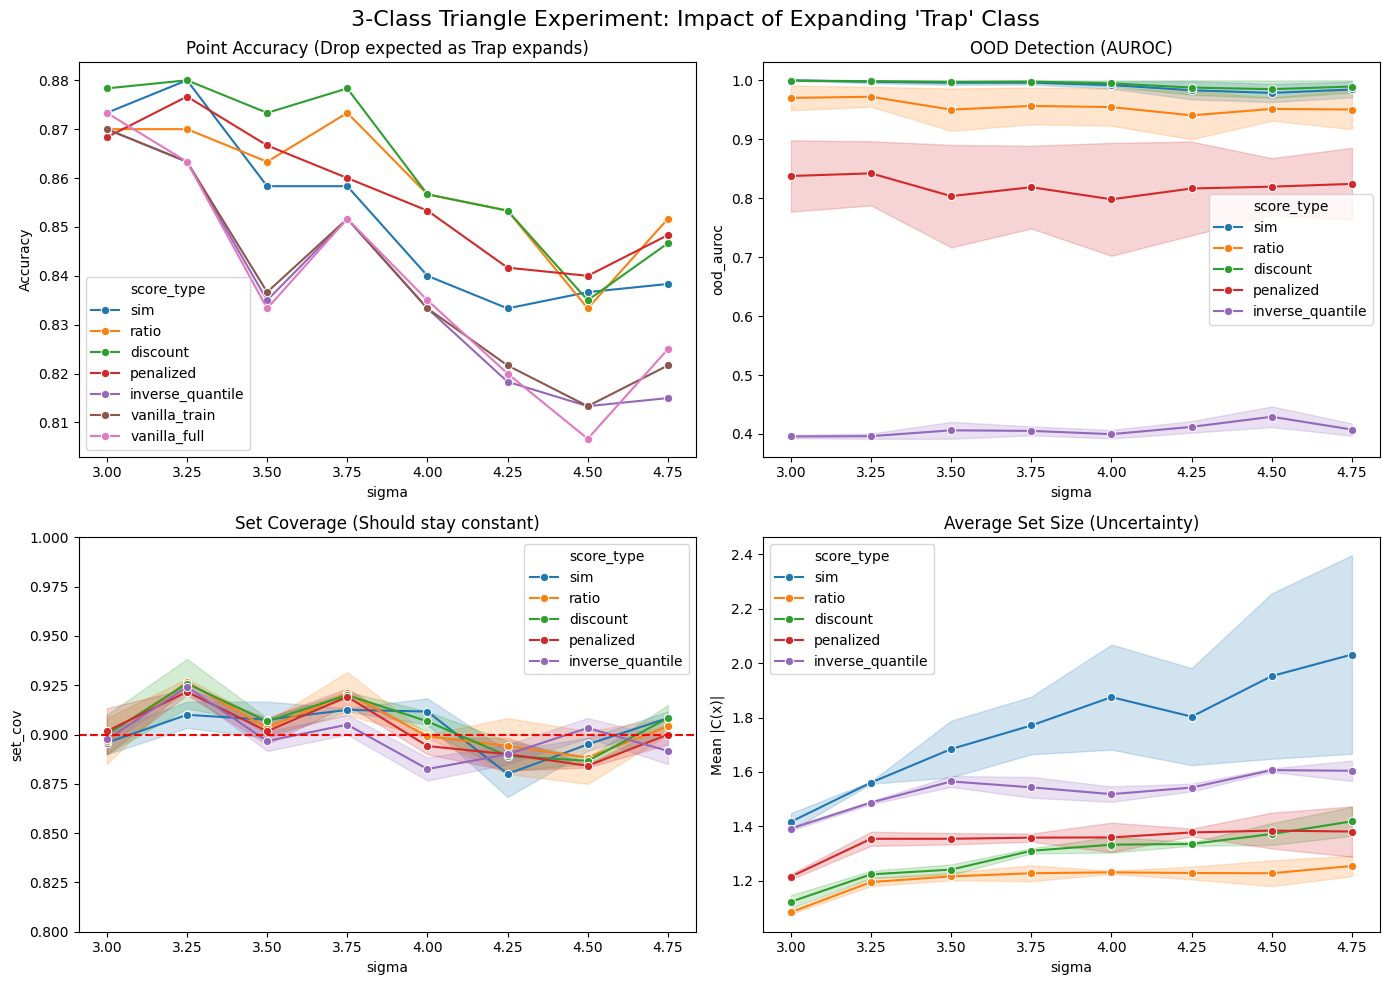

In [12]:
# Helper to plot with confidence intervals
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# 1. Point Accuracy
sns.lineplot(data=final_df, x="sigma", y="point_acc", hue="score_type", ax=axes[0,0], marker='o')
axes[0,0].set_title("Point Accuracy (Drop expected as Trap expands)")
axes[0,0].set_ylabel("Accuracy")

# 2. OOD AUROC
# Filter out Vanilla (NaN)
sns.lineplot(data=final_df.dropna(subset=['ood_auroc']), x="sigma", y="ood_auroc", hue="score_type", ax=axes[0,1], marker='o')
axes[0,1].set_title("OOD Detection (AUROC)")

# 3. Set Coverage
sns.lineplot(data=final_df.dropna(subset=['set_cov']), x="sigma", y="set_cov", hue="score_type", ax=axes[1,0], marker='o')
axes[1,0].axhline(1-alpha, color='red', linestyle='--', label='Target (90%)')
axes[1,0].set_title("Set Coverage (Should stay constant)")
axes[1,0].set_ylim(0.8, 1.0)

# 4. Set Size
sns.lineplot(data=final_df.dropna(subset=['set_size']), x="sigma", y="set_size", hue="score_type", ax=axes[1,1], marker='o')
axes[1,1].set_title("Average Set Size (Uncertainty)")
axes[1,1].set_ylabel("Mean |C(x)|")

plt.suptitle("3-Class Triangle Experiment: Impact of Expanding 'Trap' Class", fontsize=16)
plt.tight_layout()
plt.show()